In [23]:
MODEL_TYPE = "resnet18"
%run -i ./notebooks/data_preprocessing.ipynb

Images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Loaded the existing split.
{'train': 18900, 'validation': 5400, 'test': 2700}
Using the resnet18 pipeline.
Train: 18900
Validation: 5400
Test: 2700
Image batch: torch.Size([64, 3, 64, 64])
Label batch: torch.Size([64])
Data type: torch.float32


In [24]:
import numpy
from torch import nn
from torch.optim import lr_scheduler
from torchvision import models
import matplotlib.pyplot as plt

In [25]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [26]:
def training_loop(dataloader, model, loss_fn, optimizer):
  model.train()
  size = len(dataloader.dataset)
  total_loss = 0
  total = 0
  correct = 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total += y.size(0)
    _, predicted = torch.max(pred.data, 1)
    correct += (predicted == y).sum().item()
    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
  avg_training_loss = total_loss/len(dataloader)
  training_accuracy = (correct/total)*100 # Corrected calculation
  print(f"\nTraining Accuracy: {training_accuracy}% | Avg Training Loss: {avg_training_loss}")

def validation_loop(dataloader, model, loss_fn, test):
  y_true = []
  y_pred = []
  model.eval()
  size = len(dataloader.dataset)
  with torch.no_grad():
    total_loss = 0
    total = 0
    correct = 0
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      pred = model(X)
      y_pred.extend((pred.argmax(dim=1)).cpu().numpy())
      y_true.extend(y.cpu().numpy())
      total_loss += loss_fn(pred, y).item()
      total += y.size(0)
      _, predicted = torch.max(pred.data, 1)
      correct += (predicted == y).sum().item()
    avg_testing_loss = total_loss/len(dataloader)
    testing_accuracy = (correct/total)*100 # Corrected calculation
    print(f"Validation Accuracy: {testing_accuracy}% | Avg Validation Loss: {avg_testing_loss} \n")
    return avg_testing_loss, testing_accuracy, y_true, y_pred

In [27]:
# We aren't gonna freeze any layers, we are just making a new final classification layer as from previous experiments we found that fully fine tuning resnet18 gives the best results
model_ft = models.resnet18(weights = 'IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features #getting the number of inputs for the last FC layer 
model_ft.fc = nn.Linear(num_ftrs, 10) #replacing the old FC layer with a new one which now outputs 10 values instead of the previous 1000 in resnet18
model_ft = model_ft.to(device)

In [28]:
loss_fn_ft = nn.CrossEntropyLoss()
epochs_ft = 20
optimizer_ft = torch.optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
best_val_loss_ft = 100
for t in range(epochs_ft):
    print(f"Epoch {t+1}\n-------------------------------")
    training_loop(train_dataloader, model_ft, loss_fn_ft, optimizer_ft)
    val_loss, val_acc, _, _ = validation_loop(validate_dataloader, model_ft, loss_fn_ft, False)
    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        torch.save(model_ft.state_dict(), "resnet_fully_fine_tuned.pth")
print("Testing \n-------------------------------")
model_ft.load_state_dict(torch.load("resnet_fully_fine_tuned.pth", weights_only= True))
test_loss, test_acc, y_true, y_pred = validation_loop(test_dataloader, model_ft, loss_fn_ft, True)
print("Done!")

Epoch 1
-------------------------------
loss: 2.507756  [    0/18900]
loss: 0.381448  [ 6400/18900]
loss: 0.266261  [12800/18900]

Training Accuracy: 82.07936507936508% | Avg Training Loss: 0.5626549374412846
Validation Accuracy: 92.2962962962963% | Avg Validation Loss: 0.2458714832277859 

Epoch 2
-------------------------------
loss: 0.255118  [    0/18900]
loss: 0.175674  [ 6400/18900]
loss: 0.073385  [12800/18900]

Training Accuracy: 91.75661375661376% | Avg Training Loss: 0.24106034528262713
Validation Accuracy: 94.38888888888889% | Avg Validation Loss: 0.17134761253700537 

Epoch 3
-------------------------------
loss: 0.167997  [    0/18900]
loss: 0.149367  [ 6400/18900]
loss: 0.161795  [12800/18900]

Training Accuracy: 93.28571428571428% | Avg Training Loss: 0.19594408679954908
Validation Accuracy: 95.12962962962963% | Avg Validation Loss: 0.14282263326732553 

Epoch 4
-------------------------------
loss: 0.070339  [    0/18900]
loss: 0.105035  [ 6400/18900]
loss: 0.126392  [1

## Analysis

### Confusion Matrix

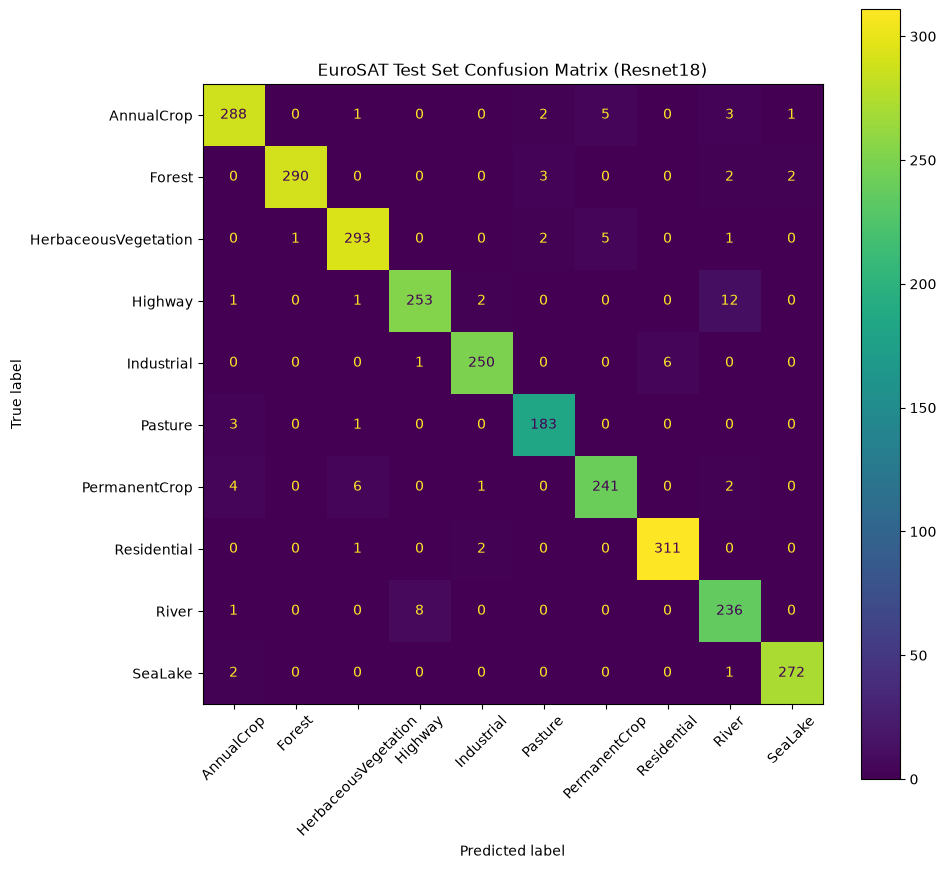

In [30]:
# Confusion Matrix

import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = base_dataset.classes
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("EuroSAT Test Set Confusion Matrix (Resnet18)")
plt.show()

plt.show()

### Classification Report

In [31]:
from sklearn.metrics import classification_report
cr = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print(cr)

                      precision    recall  f1-score   support

          AnnualCrop      0.963     0.960     0.962       300
              Forest      0.997     0.976     0.986       297
HerbaceousVegetation      0.967     0.970     0.969       302
             Highway      0.966     0.941     0.953       269
          Industrial      0.980     0.973     0.977       257
             Pasture      0.963     0.979     0.971       187
       PermanentCrop      0.960     0.949     0.954       254
         Residential      0.981     0.990     0.986       314
               River      0.918     0.963     0.940       245
             SeaLake      0.989     0.989     0.989       275

            accuracy                          0.969      2700
           macro avg      0.968     0.969     0.969      2700
        weighted avg      0.970     0.969     0.969      2700

